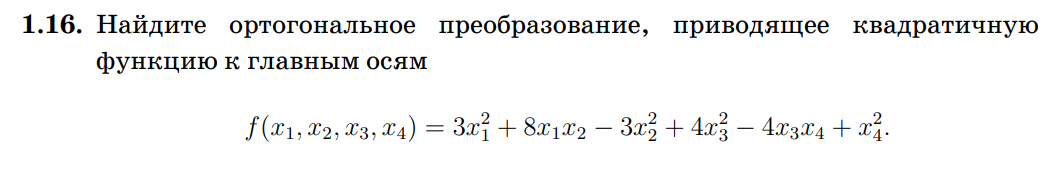

# Теория по ортогональному преобразованию и приведению квадратичной формы к главным осям

# 1. Квадратичная форма

## Определение

Квадратичная форма от $n$ переменных — это выражение вида:

$$
f(x_1,\dots,x_n)=\sum_{i,j=1}^{n}a_{ij}x_ix_j
$$

В матричном виде:

$$
f(x)=x^TAx
$$

где:

- $x$ — столбец переменных:

$$
x=
\begin{pmatrix}
x_1\\
x_2\\
\dots\\
x_n
\end{pmatrix}
$$

- $A$ — симметричная матрица:

$$
A=A^T
$$


Для симметрических матриц выполняется теорема:

> Любая вещественная симметричная матрица может быть приведена к диагональному виду с помощью ортогонального преобразования.


---

# 2. Собственные значения и собственные векторы

Собственный вектор $v$ и собственное значение $\lambda$ определяются уравнением:

$$
Av=\lambda v
$$

где:

- $v$ — собственный вектор;
- $\lambda$ — собственное значение.


Переносим всё в левую часть:

$$
(A-\lambda I)v=0
$$

Чтобы существовало ненулевое решение:

$$
\det(A-\lambda I)=0
$$

Это характеристическое уравнение.


---

# 3. Нахождение собственных значений и собственных векторов

Для поиска собственных значений составляется матрица:

$$
A-\lambda I
$$

Для каждого найденного $\lambda$ решаем:

$$
(A-\lambda I)v=0
$$

---

# 4. Норма и нормировка вектора

Для ортогонального преобразования нужны единичные векторы.

Длина вектора:

$$
||v||=\sqrt{x_1^2+x_2^2+\dots+x_n^2}
$$

Нормировка:

$$
e=\frac{v}{||v||}
$$


---

# 5. Ортогональность векторов

Два вектора называются ортогональными, если их скалярное произведение равно нулю:

$$
u\cdot v=0
$$


Или:

$$
u^Tv=0
$$


---

# 6. Ортогональная матрица

Матрица $P$ называется ортогональной, если:

$$
P^TP=I
$$


Отсюда:

$$
P^{-1}=P^T
$$


Столбцы ортогональной матрицы образуют ортонормированный базис.


---

# 7. Ортогональное преобразование координат

Выполняется замена:

$$
x=Py
$$


где:

- $x$ — старые координаты;
- $y$ — новые координаты;
- $P$ — ортогональная матрица перехода.


Исходная форма:

$$
f=x^TAx
$$


Подставляем:

$$
f=(Py)^TA(Py)
$$


Так как:

$$
(Py)^T=y^TP^T
$$


получаем:

$$
f=y^TP^TAPy
$$


Обозначим:

$$
D=P^TAP
$$


Тогда:

$$
f=y^TDy
$$


---

# 8. Главный вид квадратичной формы

После ортогонального преобразования матрица становится диагональной:

$$
D=
\begin{pmatrix}
\lambda_1&0&\dots&0\\
0&\lambda_2&\dots&0\\
\dots&\dots&\dots&\dots\\
0&0&\dots&\lambda_n
\end{pmatrix}
$$


Квадратичная форма принимает вид:

$$
f=\lambda_1y_1^2+\lambda_2y_2^2+\dots+\lambda_ny_n^2
$$


То есть собственные значения становятся коэффициентами при квадратах новых переменных.



In [2]:
import sympy as sp

# -----------------------------
# 1. Матрица квадратичной формы
# -----------------------------

A = sp.Matrix([
    [3,  4,  0,  0],
    [4, -3,  0,  0],
    [0,  0,  4, -2],
    [0,  0, -2,  1]
])


# -----------------------------
# 2. Собственные значения и векторы
# -----------------------------

eigen = A.eigenvects()

vectors = []
eigenvalues = []

# print("\nСобственные значения и векторы:")

for lam, mult, vecs in eigen:
    # print("\nλ =", lam)

    for v in vecs:
        # print("Собственный вектор:")
        # sp.pprint(v)

        # нормировка вектора
        v_norm = v / sp.sqrt(v.dot(v))

        vectors.append(v_norm)
        eigenvalues.append(lam)


# -----------------------------
# 3. Создание ортогональной матрицы P
# -----------------------------

P = sp.Matrix.hstack(*vectors)

# print("\nОртогональная матрица P:")
# sp.pprint(P)


# -----------------------------
# 4. Проверка ортогональности
# -----------------------------

# print("\nПроверка P^T*P = I:")
#
# check = sp.simplify(P.T * P)
#
# sp.pprint(check)


# -----------------------------
# 5. Получение диагональной матрицы
# -----------------------------

D = sp.simplify(P.T * A * P)

# print("\nДиагональная матрица D = P^T*A*P:")
# sp.pprint(D)


# -----------------------------
# 6. Новый вид квадратичной формы
# -----------------------------

y1, y2, y3, y4 = sp.symbols('y1 y2 y3 y4')

y = sp.Matrix([
    y1,
    y2,
    y3,
    y4
])


f_new = (y.T * D * y)[0]

print("\nКвадратичная форма в новых координатах:")
sp.expand(f_new)


Квадратичная форма в новых координатах:


-5*y1**2 + 5*y3**2 + 5*y4**2